# 2CSSID-Workshop04. Association Rules

<p style='text-align: right;font-style: italic; color: red;'>Designed by: Mr. Abdelkrime Aries; Translated by: Mr. Google Translate</p>
<p style='text-align: right;font-style: italic; color: blue;'>If the translation is good, it is I who takes credit; Otherwise, blame Google Translate</p>

In this workshop, we will implement association rules with the APriori function.
Then, we will compare between the itemset generation methods: APriori, FPmax and FPgrowth.
Also, we will test the effect of hyper-parameters like confidence and lift.

In [1]:
import matplotlib
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
%matplotlib inline

np.__version__, pd.__version__, matplotlib.__version__

('2.3.3', '2.3.3', '3.10.7')

In [2]:
from typing import Tuple, List, Type, Dict

## I. Algorithms implementation

In this part, we will implement the association rules with the A-Priori function.
Each transaction (row) is represented by a vector of size $|I|$ where $I$ is the list of items.
When there is a $1$, the item is seen in the transaction; $0$ otherwise.
So, an item (column) can be represented by the transactions where it was seen.

In [3]:
# No implementation here
# the function is used to transform the list of transactions
# to a list of (1 or 1)
def transform_transactions(transactions: List[str]) -> Tuple[np.ndarray, List[str]]:
    count_vectorizer = CountVectorizer(token_pattern=r'(?u)\b\w+\b')
    X = count_vectorizer.fit_transform(transactions)
    return X.toarray(), count_vectorizer.get_feature_names_out().tolist()

example_lecture = [
    'A,C,D',
    'B,C,E',
    'A,B,C,E',
    'B,E',
    'A,B,C,E',
    'B,C,E'
]

# This will be used as an example later
X_tst, titles = transform_transactions(example_lecture)

# Display transactions X items
pd.DataFrame(X_tst, columns=titles)

,a,b,c,d,e
0,1,0,1,1,0
1,0,1,1,0,1
2,1,1,1,0,1
3,0,1,0,0,1
4,1,1,1,0,1
5,0,1,1,0,1


### I.1. Frequent itemsets

In our case, a transaction is represented as an item: a vector of transactions ($0$ or $1$).

#### I.1.1. Creating an itemset

Given two itemsets $I_1$ and $I_2$, merging the two results in an itemset of the same size where transactions containing $1$ in both must contain $1$; $0$ otherwise.

$$I_3 = I_1 \cap I_2$$

$$I_3[i] = \begin{cases}1 & \text{if } I_1[i]= 1 \text{ and } I_2[i] = 1\\0 & \text{otherwise}\\\end{cases}$$

In [4]:
# TODO: Merging two itemsets
def create_itemset(I1: np.ndarray, I2: np.ndarray) -> np.ndarray:
    
    # Ensure both itemsets have the same length
    if I1.shape != I2.shape:
        raise ValueError("Itemsets must have the same shape")

    # Create the merged itemset
    merged_itemset = np.where((I1 + I2) == 2, 1, 0)

    return merged_itemset

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# array([0, 0, 1, 0, 1, 0])
#---------------------------------------------------------------------

# {a, b}
I_ab = create_itemset(X_tst[:, 0], X_tst[:, 1])

I_ab

array([0, 0, 1, 0, 1, 0])

#### I.1.2. Support calculation

We denote: $\sigma(I)$, the support count of $I$ (Number of transactions containing $I$).
$T$ is the list of transactions.

$$Supp(I) = \frac{\text{Number of transactions containing } I}{\text{Number of transactions}} = \frac{\sigma(I)}{|T|}$$

In [5]:
# TODO: Itemset support
def calculate_support(I: List[int]) -> float:
    # Calculate the support as the ratio of transactions containing the itemset
    support = np.sum(I) / len(I)
    return float(support)

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# 0.3333333333333333
#---------------------------------------------------------------------

# Supp({a, b}) = 2/6 = 0.333333333
calculate_support(I_ab)

0.3333333333333333

#### I.1.3. Enriching a frequent itemset

To facilitate the operation of creating new itemsets, we will use another method a little different from the one in the course (same result).
Here, we assume that there already exists an accepted frequent itemset $I$ with the index of the items it contains $idx$.
We will enrich this itemset with one item at a time (if the itemset does not contain the item in its index).
If the support of the new itemset exceeds or equals the threshold, we add it to the set of itemsets.

Input of the function:

- $I$: itemset represented as a vector with the number of transactions as length. - $idx$ : a list of columns (items) that form the itemset
- $X$ : a matrix (Transactions X items)
- $threshold$ : the minimal support of the itemsets to add

As output, we generate a list of itemsets.
An itemset, in this case, is a triplet:
- List of indexes of the items
- A vector representing the itemset
- A real number representing the support


In [6]:
# TODO: extend an itemset with items
def extend_itemset(idx: List[int], 
                        I: np.ndarray,
                        X: np.ndarray, 
                        minsup: float) -> List[Tuple[List[int], np.ndarray, float]]:
    N = X.shape[1] # number of items
    
    itemsets = []
    
    #we always start with the last index
    for j in range(idx[-1], N):
        if j in idx: # we do not add an item that already exists in the itemset
            continue
        
        new_I = create_itemset(I, X[:, j])

        support = calculate_support(new_I)

        if support >= minsup:
            new_idx = idx + [j]
            itemsets.append((new_idx, new_I, support))
            
    return itemsets

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# [([0, 1, 2], array([0, 0, 1, 0, 1, 0]), 0.3333333333333333),
#  ([0, 1, 4], array([0, 0, 1, 0, 1, 0]), 0.3333333333333333)]
#---------------------------------------------------------------------

# the itemsets that can be generated from {a, b}
extend_itemset([0, 1], I_ab, X_tst, 0.1)

[([0, 1, 2], array([0, 0, 1, 0, 1, 0]), 0.3333333333333333),
 ([0, 1, 4], array([0, 0, 1, 0, 1, 0]), 0.3333333333333333)]

#### I.1.4. Creation of frequent itemsets

- For each item $X_j$ of $X$, create an itemset with a single element;
- Calculate the support of this itemset;
- If its support is greater than or equal to a threshold $minsup$, add it to the list of frequent itemsets;
- Add the itemset to a stack to be enriched later;
- As long as the stack is not empty:
   - Pop the last element (itemset),
   - Form itemsets based on this itemset,
   - Add these itemsets to the list of frequent itemsets,
   - Add them to the stack to be enriched later.

In [7]:
# TODO: Creating Frequent Itemsets
def create_frequent_itemsets(X: List[List[int]], minsup: float = 0.1) -> List[Tuple[List[int], np.ndarray, float]]:
    
    N = X.shape[1]
    
    frequent_itemsets = []
    
    
    for j in range(N):
        Xj = X[:, j]
        support = calculate_support(Xj)
        if support >= minsup:
            itemset = ([j], Xj, support)
            frequent_itemsets.append(itemset)
            pile = [itemset]
        while len(pile):
            idx, I, supp  = pile.pop()
            extended_itemsets = extend_itemset(idx, I, X, minsup)
            for new_idx, new_I, new_supp in extended_itemsets:
                frequent_itemsets.append((new_idx, new_I, new_supp))
                pile.append((new_idx, new_I, new_supp))
                
    return frequent_itemsets


#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# [([0], array([1, 0, 1, 0, 1, 0]), 0.5),
#  ([0, 2], array([1, 0, 1, 0, 1, 0]), 0.5),
#  ([1], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334),
#  ([1, 2], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
#  ([1, 4], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334),
#  ([1, 2, 4], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
#  ([2], array([1, 1, 1, 0, 1, 1]), 0.8333333333333334),
#  ([2, 4], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
#  ([4], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334)]
#---------------------------------------------------------------------

itemsets050 = create_frequent_itemsets(X_tst, minsup=0.5)

itemsets050

[([0], array([1, 0, 1, 0, 1, 0]), 0.5),
 ([0, 2], array([1, 0, 1, 0, 1, 0]), 0.5),
 ([1], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334),
 ([1, 2], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
 ([1, 4], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334),
 ([1, 2, 4], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
 ([2], array([1, 1, 1, 0, 1, 1]), 0.8333333333333334),
 ([2, 4], array([0, 1, 1, 0, 1, 1]), 0.6666666666666666),
 ([4], array([0, 1, 1, 1, 1, 1]), 0.8333333333333334)]

### I.2. Association Rules

Here, we will apply a slightly different algorithm than the one seen in class: more execution time, but simpler to perform.
The association rules are of the form $A \rightarrow B$ where $A$ and $B$ are two frequent itemsets.
This is the general version; in our case, we take $B$ as a single item (itemset with a single item).

#### I.2.1. Confidence and Lift

Given two itemsets $A$ and $B$ with their respective supports $supp(A)$ and $supp(B)$, we will calculate the support, confidence and lift of the rule $A \rightarrow B$.

$$Conf(A \rightarrow B) = \frac{\sigma(A \cap B)}{\sigma(A)}$$

$$Lift(A \rightarrow B) = \frac{Add(A \cap B)}{Add(A)\sigma(B)} = \frac{Conf(A \rightarrow B)}{Add(B)}$$

In [13]:
# TODO: Quality measures of a rule
def mesure_quality(A: np.ndarray, B: np.ndarray) -> Tuple[float, float, float]:
    support = calculate_support(create_itemset(A, B))
    confiance = support / calculate_support(A) if calculate_support(A) > 0 else 0
    lift = confiance / calculate_support(B) if calculate_support(B) > 0 else 0
    return round(support, 10), round(confiance, 10), round(lift, 10)

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# (0.6666666666666666, 0.8, 0.96)
#---------------------------------------------------------------------

# {B, E} --> {C}
mesure_quality(create_itemset(X_tst[:, 1], X_tst[:, 4]), X_tst[:, 2])

(0.6666666667, 0.8, 0.96)

#### I.2.2. Generate rules

Here, we take a list of frequent itemsets, a list of transactions and the confidence threshold as input.
A frequent itemset is represented as a tuple (list of items, vector representation, support).

- For each frequent itemset (idx, I, supp) of $IF$
- For each item $j$ of $X$
- If $j$ is not in $idx$, compute the quality measure (I --> Xj)
- The quality measure will be (support, confidence, lift)
- If the confidence is greater than the threshold, add (idx, j, support, confidence, lift) to the list of rules

In [14]:
# TODO: Generate association rules
def generate_rules(IF: List[Tuple[List[int], np.ndarray, float]], 
                    X: np.ndarray, 
                    minconf=0.1) -> List[Tuple[List[int], int, float, float, float]]:
    rules = []
    
    for idx, I, _ in IF:
        for j in range(X.shape[1]):
            if j not in idx:
                Xj = X[:, j]
                # Complete here
                support, confiance, lift = mesure_quality(I, Xj)
                if confiance >= minconf:
                    rules.append((idx, j, support, confiance, lift))    
                    
    
    return rules

#=====================================================================
# UNIT TEST
#=====================================================================
# Result: 
# [([0], 2, 0.5, 1.0, 1.2),
#  ([1], 2, 0.6666666666666666, 0.8, 0.96),
#  ([1], 4, 0.8333333333333334, 1.0, 1.2),
#  ([1, 2], 4, 0.6666666666666666, 1.0, 1.2),
#  ([1, 4], 2, 0.6666666666666666, 0.8, 0.96),
#  ([2], 1, 0.6666666666666666, 0.8, 0.96),
#  ([2], 4, 0.6666666666666666, 0.8, 0.96),
#  ([2, 4], 1, 0.6666666666666666, 1.0, 1.2),
#  ([4], 1, 0.8333333333333334, 1.0, 1.2),
#  ([4], 2, 0.6666666666666666, 0.8, 0.96)]
#---------------------------------------------------------------------

regles = generate_rules(itemsets050, X_tst, minconf=0.8)

regles

[([0], 2, 0.5, 1.0, 1.2),
 ([1], 2, 0.6666666667, 0.8, 0.96),
 ([1], 4, 0.8333333333, 1.0, 1.2),
 ([1, 2], 4, 0.6666666667, 1.0, 1.2),
 ([1, 4], 2, 0.6666666667, 0.8, 0.96),
 ([2], 1, 0.6666666667, 0.8, 0.96),
 ([2], 4, 0.6666666667, 0.8, 0.96),
 ([2, 4], 1, 0.6666666667, 1.0, 1.2),
 ([4], 1, 0.8333333333, 1.0, 1.2),
 ([4], 2, 0.6666666667, 0.8, 0.96)]

### I.3. Final product

**Nothing to code here**

In [15]:
def create_title(idx: List[int], titles: List[str]) -> str:
    titre = '{' + titles[idx[0]]
    for i in range(1, len(idx)):
        titre += ',' + titles[idx[i]]
    return titre + '}'

In [16]:
class APrioriRA():
    def __init__(self, minsup= 0.1, minconf=0.1):
        self.minsup = minsup
        self.minconf = minconf
        
    def fit(self, transactions: List[str]):
        X_apriori, self.titles = transform_transactions(transactions)
        IF = create_frequent_itemsets(X_apriori, minsup = self.minsup)
        regles = generate_rules(IF, X_apriori, minconf=self.minconf)
        # Order by confidence value
        regles.sort(key=lambda tup: tup[3], reverse=True)
        self.regles = regles
        
    def pandas_dataframe(self):
        if not self.titles:
            return None
        data = []
        for ant, conc, sup, conf, lift in self.regles:
            ant_ens = create_title(ant, self.titles)
            conc_ens = create_title([conc], self.titles)
            data.append([ant_ens, conc_ens, sup, conf, lift])
        colonnes_t = ['antecedent', 'conclusion', 'support', 'confiance', 'lift']
        return pd.DataFrame(data, columns=colonnes_t)

apriori = APrioriRA(minsup=0.5, minconf=0.8)
apriori.fit(example_lecture)
apriori.pandas_dataframe()

,antecedent,conclusion,support,confiance,lift
0,{a},{c},0.500000,1.0,1.20
1,{b},{e},0.833333,1.0,1.20
2,"{b,c}",{e},0.666667,1.0,1.20
3,"{c,e}",{b},0.666667,1.0,1.20
4,{e},{b},0.833333,1.0,1.20
5,{b},{c},0.666667,0.8,0.96
6,"{b,e}",{c},0.666667,0.8,0.96
7,{c},{b},0.666667,0.8,0.96
8,{c},{e},0.666667,0.8,0.96
9,{e},{c},0.666667,0.8,0.96


## II. Application and Analsis



In [ ]:
# installing mlxtend package
# !pip install mlxtend

In [18]:
shop_list = [
    '7lib,khobz,gateau',
    'khobz,7lib,gateau,jus',
    'khobz,tai,zabda',
    'confiture,chocolat,khobz,7lib',
    'chocolat,tai,gateau',
    'khobz,tai,zabda',
    'chocolat,tai,jus',
    'chocolat,khobz,tai,gateau',
    'confiture,chocolat,khobz,tai',
    'khobz,7lib',
    'qahwa,fromage,gateau,jus',
    'qahwa,fromage,gateau,jus',
    'qahwa,sakkar,zabda',
    'khobz,qahwa,fromage',
    'khobz,sakkar,gateau',
    'qahwa,sakkar,jus',
    'khobz,sakkar,zabda',
    'khobz,qahwa,sakkar',
    'khobz,qahwa,sakkar',
    'tai,7lib,qahwa,jus'
]

data_shop = []
# data_achat_grand = []
for transaction in shop_list:
    t = transaction.split(',')
    data_shop.append(t)
#     for i in range(100):
#         data_achat_grand.append(t)

data_shop[:2]

[['7lib', 'khobz', 'gateau'], ['khobz', '7lib', 'gateau', 'jus']]

In [19]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(data_shop).transform(data_shop)
df = pd.DataFrame(te_ary, columns=te.columns_)

# te_grand = TransactionEncoder()
# te_ary_grand = te_grand.fit(data_achat_grand).transform(data_achat_grand)
# df_grand = pd.DataFrame(te_ary_grand, columns=te_grand.columns_)

df

,7lib,chocolat,confiture,fromage,gateau,jus,khobz,qahwa,sakkar,tai,zabda
0,True,False,False,False,True,False,True,False,False,False,False
1,True,False,False,False,True,True,True,False,False,False,False
2,False,False,False,False,False,False,True,False,False,True,True
3,True,True,True,False,False,False,True,False,False,False,False
4,False,True,False,False,True,False,False,False,False,True,False
5,False,False,False,False,False,False,True,False,False,True,True
6,False,True,False,False,False,True,False,False,False,True,False
7,False,True,False,False,True,False,True,False,False,True,False
8,False,True,True,False,False,False,True,False,False,True,False
9,True,False,False,False,False,False,True,False,False,False,False


### II.1. Itemset generation

Here we will test the effect of some parameters of itemset generation.

#### II.1.1. Comparison between generation methods

Here we want to compare between methods:

- A Priori
- FPmax
- FPgrowth

We will use the execution time as a comparison metric.

To be sure, we will run the algorithms several times.

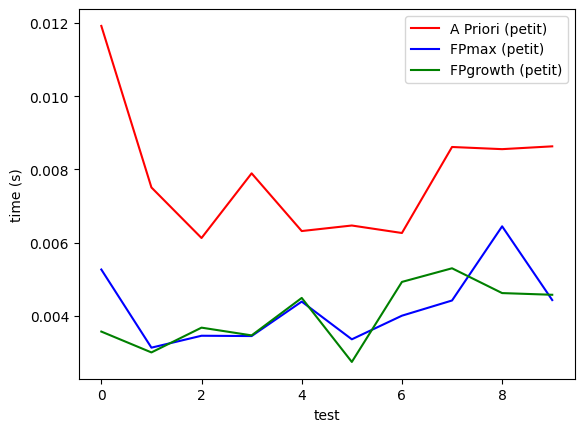

In [20]:
from mlxtend.frequent_patterns import apriori, fpmax, fpgrowth
import timeit

NBR_IT = 10

te = TransactionEncoder()
te_ary = te.fit(data_shop).transform(data_shop)
df = pd.DataFrame(te_ary, columns=te.columns_)

temps = [[], [], [], [], [], []]

algos = [apriori, fpmax, fpgrowth]

for it in range(NBR_IT):
    for i, algo in enumerate(algos):
        temps_debut = timeit.default_timer()
        FI = algo(df, min_support=0.1, use_colnames=True)
        temps[i].append(timeit.default_timer() - temps_debut)
        
#         temps_debut = timeit.default_timer()
#         FI = algo(df_grand, min_support=0.1, use_colnames=True)
#         temps[i+3].append(timeit.default_timer() - temps_debut)

plt.plot(temps[0], label='A Priori (petit)', color='red')
plt.plot(temps[1], label='FPmax (petit)', color='blue')
plt.plot(temps[2], label='FPgrowth (petit)', color='green')

# plt.plot(temps[3], label='A Priori (grand)', color='red', linestyle='--')
# plt.plot(temps[4], label='FPmax (grand)', color='blue', linestyle='--')
# plt.plot(temps[5], label='FPgrowth (grans)', color='green', linestyle='--')

plt.xlabel('test')
plt.ylabel('time (s)')
plt.legend()
plt.show()

**TODO: Analyze the results**

- What do you notice?
- Why does the APriori method take longer?

**Answer**

- The execution time plot shows that the Apriori algorithm consistently takes longer than FP-Growth and FP-Max across repeated runs

- Apriori requires multiple scans of the dataset and generates a large number of candidate itemsets at each iteration. Each candidate must be evaluated against the entire transaction database, leading to high computational cost. In contrast, FP-Growth and FP-Max compress the data into an FP-tree structure and mine frequent patterns without explicit candidate generation. This reduces redundant computations and explains their superior performance in terms of execution time.

#### II.1.2. Effect of minimal support

We want to test the effect of minimal support on the creation of frequent itemsets.
To do this, we will use FPgrowth with different values ​​of this parameter.


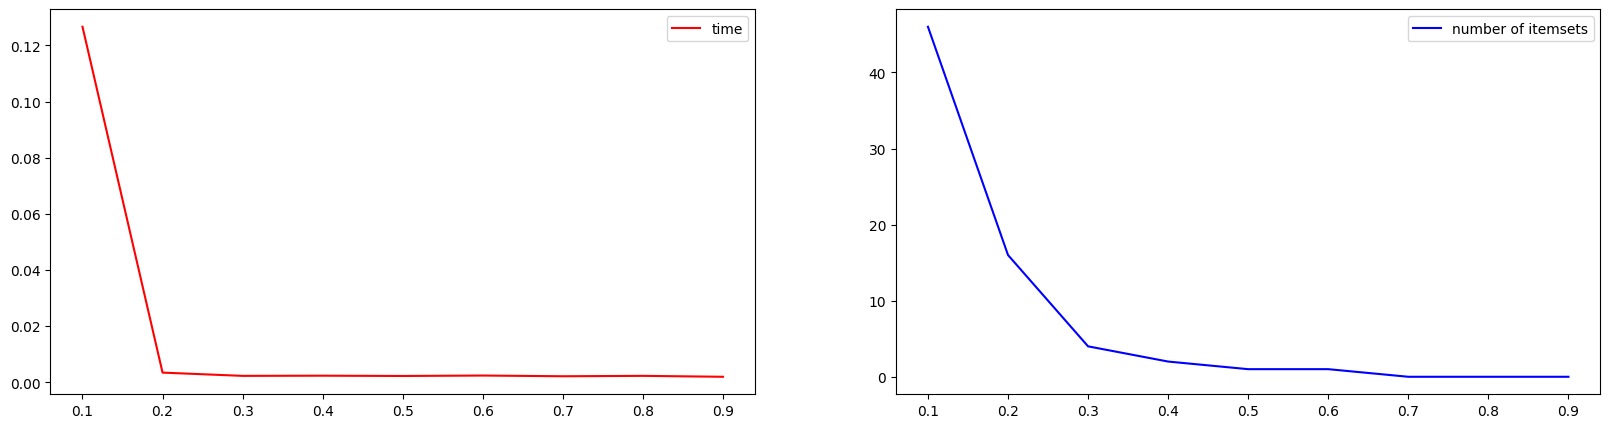

In [24]:
min_supports = np.arange(0.1, 1, 0.1)

temps_sm = []
itemsets_nbr = []

for min_support in min_supports:
    temps_debut = timeit.default_timer()
    FI = fpgrowth(df, min_support=min_support, use_colnames=True)
    temps_sm.append(timeit.default_timer() - temps_debut)
    
    itemsets_nbr.append(FI.shape[0])

    
fig, axs = plt.subplots(1, 2, figsize=(20,5))

axs[0].plot(min_supports, temps_sm, label='time', color='red')
axs[0].legend()
axs[1].plot(min_supports, itemsets_nbr, label='number of itemsets', color='blue')
axs[1].legend()
plt.show()


**TODO: Analyze the results**

- What do you notice?
- Justify.

**Answer**

- As the minimum support increases, the number of generated frequent itemsets decreases sharply. At the same time, the execution time of FP-Growth decreases, reaching very low values for high support thresholds. This indicates a strong inverse relationship between the minimum support value and both the complexity and size of the frequent itemset space.

- A higher minimum support imposes a stricter frequency constraint, which eliminates a large number of candidate patterns early in the mining process. As a result, fewer itemsets need to be explored and stored, reducing both memory usage and computation time. Conversely, lower support thresholds allow many rare item combinations to be considered frequent, significantly increasing the search space and the cost of mining. This explains the longer execution times observed for small support values, even when using an efficient algorithm such as FP-Growth.

### II.2. Association rules generation

Here, we want to test the effect of some parameters on the generation of association rules.
We will use the same frequent itemsets.


In [25]:
FI_01 = fpgrowth(df, min_support=0.1, use_colnames=True)

FI_01.tail()

,support,itemsets
41,0.1,"(fromage, jus, gateau)"
42,0.1,"(fromage, qahwa, jus, gateau)"
43,0.2,"(sakkar, qahwa)"
44,0.2,"(sakkar, khobz)"
45,0.1,"(sakkar, qahwa, khobz)"


In [26]:
FI_02 = fpgrowth(df, min_support=0.2, use_colnames=True)

FI_02.tail()

,support,itemsets
11,0.2,"(qahwa, jus)"
12,0.2,"(khobz, tai)"
13,0.2,"(chocolat, tai)"
14,0.2,"(sakkar, qahwa)"
15,0.2,"(sakkar, khobz)"


#### II.2.1. Rule selection metric

Here, we want to test the effect of the metric used to generate the association rules:

- Confidence
- Lift

In [ ]:
from mlxtend.frequent_patterns import association_rules

association_rules(FI_02, 5, metric='confidence', min_threshold=0.6)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(7lib),(khobz),0.25,0.65,0.2,0.800000,1.230769,1.0,0.0375,1.75,0.250000,0.285714,0.428571,0.553846
1,(jus),(qahwa),0.30,0.40,0.2,0.666667,1.666667,1.0,0.0800,1.80,0.571429,0.400000,0.444444,0.583333
2,(chocolat),(tai),0.25,0.35,0.2,0.800000,2.285714,1.0,0.1125,3.25,0.750000,0.500000,0.692308,0.685714
3,(sakkar),(qahwa),0.30,0.40,0.2,0.666667,1.666667,1.0,0.0800,1.80,0.571429,0.400000,0.444444,0.583333
4,(sakkar),(khobz),0.30,0.65,0.2,0.666667,1.025641,1.0,0.0050,1.05,0.035714,0.266667,0.047619,0.487179


In [28]:
association_rules(FI_02, 5, metric='lift', min_threshold=1.2)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(7lib),(khobz),0.25,0.65,0.2,0.800000,1.230769,1.0,0.0375,1.750000,0.250000,0.285714,0.428571,0.553846
1,(khobz),(7lib),0.65,0.25,0.2,0.307692,1.230769,1.0,0.0375,1.083333,0.535714,0.285714,0.076923,0.553846
2,(qahwa),(jus),0.40,0.30,0.2,0.500000,1.666667,1.0,0.0800,1.400000,0.666667,0.400000,0.285714,0.583333
3,(jus),(qahwa),0.30,0.40,0.2,0.666667,1.666667,1.0,0.0800,1.800000,0.571429,0.400000,0.444444,0.583333
4,(chocolat),(tai),0.25,0.35,0.2,0.800000,2.285714,1.0,0.1125,3.250000,0.750000,0.500000,0.692308,0.685714
5,(tai),(chocolat),0.35,0.25,0.2,0.571429,2.285714,1.0,0.1125,1.750000,0.865385,0.500000,0.428571,0.685714
6,(sakkar),(qahwa),0.30,0.40,0.2,0.666667,1.666667,1.0,0.0800,1.800000,0.571429,0.400000,0.444444,0.583333
7,(qahwa),(sakkar),0.40,0.30,0.2,0.500000,1.666667,1.0,0.0800,1.400000,0.666667,0.400000,0.285714,0.583333


**TODO: Analyze the results**

- Is the result of one metric included in the other? Why?
- Why are there rules that have a big lift yet they have a small confidence (antecedent, consequence)?

**Answer**

- The rules generated using confidence and lift as selection metrics partially overlap but are not identical. Confidence ranks rules by reliability, i.e., the probability that the consequent occurs when the antecedent occurs, while lift ranks rules by statistical dependence between antecedent and consequent. Therefore, some rules with high confidence may have low lift if the consequent is very frequent, and vice versa, which explains why neither metric completely includes the other.

- Lift measures the strength of association relative to independence, so a rule can have a high lift if the antecedent significantly increases the likelihood of a rare consequent, even when the absolute confidence is small. In other words, lift captures relative importance, not absolute probability, which explains why some low-confidence rules appear very significant according to lift. This highlights that confidence alone may miss important but infrequent associations in the dataset.

#### II.2.2. Minimum threshold

Here we want to test the effect of the minimum threshold.
We will use confidence as a metric.
So, we change the minimum confidence and calculate the properties:
- Time to create rules;
- Number of generated rules;
- Maximum length of the antecedent.

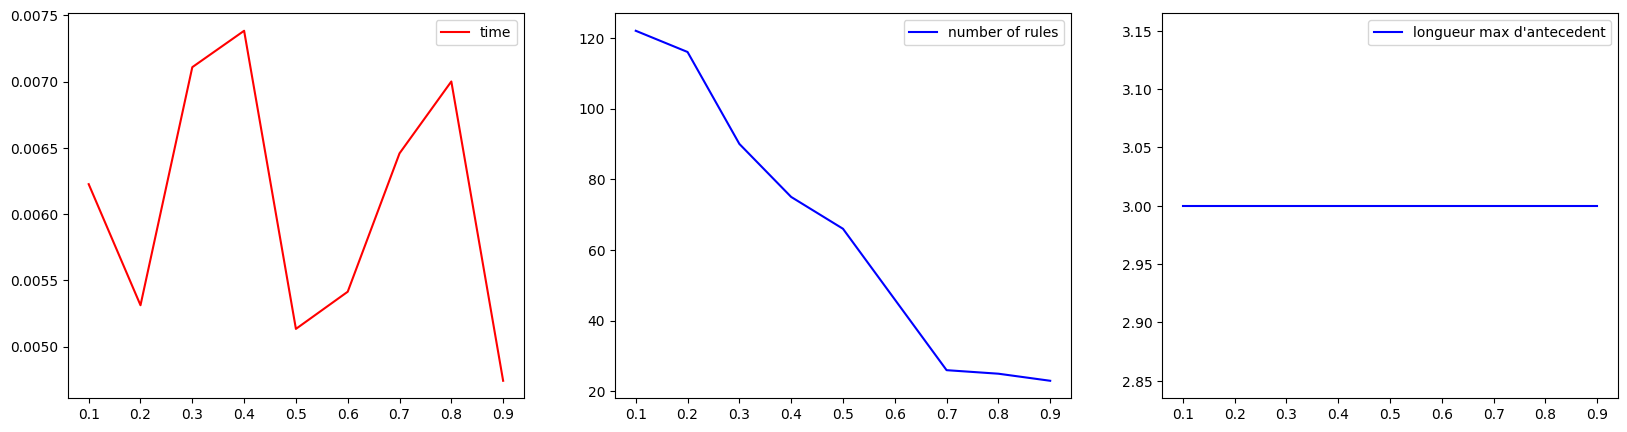

In [29]:
min_confiances = np.arange(0.1, 1, 0.1)

temps_regles = []
nbr_regles = []
antecedent_max_nbrs = []

for min_confiance in min_confiances:
    temps_debut = timeit.default_timer()
    regles = association_rules(FI_01, 5, metric='confidence', min_threshold=min_confiance)
    temps_regles.append(timeit.default_timer() - temps_debut)
    
    nbr_regles.append(regles.shape[0])
    
    antecedent_nbrs = regles['antecedents'].apply(lambda x: len(x))
    antecedent_max_nbrs.append(antecedent_nbrs.max())

    
fig, axs = plt.subplots(1, 3, figsize=(20,5))

axs[0].plot(min_confiances, temps_regles, label='time', color='red')
axs[0].legend()
axs[1].plot(min_confiances, nbr_regles, label='number of rules', color='blue')
axs[1].legend()
axs[2].plot(min_confiances, antecedent_max_nbrs, label='longueur max d\'antecedent', color='blue')
axs[2].legend()
plt.show()

**TODO: Analyze the results**

- What do you notice? by deducing if the min number affects one of the three properties.

**Answer**

- By examining the results, we observe that increasing the minimum confidence threshold has a clear impact on two of the three measured properties. First, the number of generated rules decreases as the threshold increases. This is expected because a higher confidence requirement filters out weaker associations, leaving only rules that are strongly supported by the data. Consequently, the computational load decreases, and we also notice a slight reduction in the time to create rules, as fewer candidate rules need to be evaluated and stored.
However, the maximum length of antecedents remains constant at 3 across all confidence thresholds. This indicates that the longest antecedents are constrained by the dataset itself, rather than by the confidence parameter. Even with stricter confidence requirements, the algorithm cannot generate antecedents longer than the transactions allow. In summary, the minimum confidence threshold directly affects the number of rules and the rule generation time, but it does not affect the maximum length of antecedents, which is determined by the dataset’s structure.